# AI Data Analyst with Parallel Graph Generation

## Automated SQL and Data Visualization

**The Problem:**
I have a massive trove of sales data, but their business team can't access insights fast enough. Every time a manager asks, "What were the top 5 sales countries last quarter?", a data analyst has to:
1. Write and execute a SQL query.
2. Export the data to a CSV.
3. Load it into a Pandas DataFrame.
4. Write Matplotlib code to generate a chart.
5. Write a summary of the findings.

This manual ETL and visualization pipeline takes hours, and the analytics team is bottlenecked. They need an AI agent that can ingest a natural language question, fetch the data, and simultaneously generate a Python-based chart and a human-readable summary.

## Why LangGraph? The Power of Parallel Nodes

Standard agents run linearly (Step A → Step B → Step C). But a senior data analyst multitasks. Once the data is retrieved, the agent should ideally generate the chart AND write the description at the exact same time to reduce latency.

With LangGraph, we can use **Parallel Execution** (Fan-out / Fan-in).
* **Fan-out:** The state splits. One node writes the Matplotlib code; another node calls the LLM to write a 2-line summary based on the raw data.
* **Fan-in:** A response aggregator node waits for both parallel tasks to finish, combines the chart and text, and delivers the final payload to the user.

This makes the agent significantly faster and perfectly mimics a real-world analytics workflow.

## The Architecture: DataViz Analyst Agent

Here is the workflow we are building :

```text
                       User: "Show me a chart of the top 5 countries by sales"
                                                  │
                                                  ▼
                                       ┌──────────────────────┐
                                       │   Query Analyzer     │ ◄── LLM decides if this needs SQL
                                       │   (Routing Node)     │     and generates the query
                                       └────────┬─────────────┘
                                                │
                                                ▼
                                    ┌─────────────────────────┐
                                    │   Database Tool         │ ◄── Executes SQL against SQLite/CSV
                                    │   (Fetch Data)          │
                                    └───────────┬─────────────┘
                                                │ (Data Retrieved)
                                          ┌─────┴─────────────┐
                                          │ Fan-out           │ ◄── Parallel Execution Starts
                                          ▼                   ▼
                                    ┌─────────┐        ┌──────────────┐
                                    │ Chart   │        │ Description  │ ◄── 1. Matplotlib generates graph
                                    │ Node    │        │ Node         │     2. LLM writes 2-line summary
                                    └─────────┘        └──────────────┘
                                        │                      │
                                        ▼                      ▼
                                        └───────────┬──────────┘
                                                    │ Fan-in
                                                    ▼
                                         ┌──────────────────────┐
                                         │ Response Aggregator  │ ◄── Combines graph + summary
                                         └──────────────────────┘
                                                    │
                                                    ▼
                                                   END

### Step 0: Install the Required Packages

To build the DataViz Analyst Agent, we need our graph framework, our LLM bridge, and our standard data science toolkit:
- **`langgraph`** — The orchestration framework for our parallel agent.
- **`langchain-groq`** — our fast, free, and smart LLM brain.
- **`pandas` & `sqlalchemy`** — For data manipulation and querying our SQL database.
- **`matplotlib`** — To generate the visual charts.

### Step 2: Create "Database"

To test our agent, we need some actual data. We will simulate our data warehouse by creating a local SQLite database and loading it with some mock global sales data using Pandas. 

This gives our agent a real SQL engine to interact with when it decides to run queries.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import random
from datetime import timedelta, date

np.random.seed(42)
random.seed(42)
num_records = 500

countries = ["USA", "UK", "India", "Germany", "Canada", "Australia", "Japan", "France"]
products = ["Laptop", "Monitor", "Tablet", "Phone", "Headphones", "Keyboard", "Mouse"]
segments = ["Consumer", "Corporate", "Home Office"]


start_date = date(2025, 1, 1)
dates = [start_date + timedelta(days=random.randint(0, 365)) for _ in range(num_records)]

data = {
    "order_id": range(1001, 1001 + num_records),
    "date": sorted([d.strftime("%Y-%m-%d") for d in dates]), # Sorted so line charts look natural
    "country": np.random.choice(countries, num_records),
    "product": np.random.choice(products, num_records),
    "segment": np.random.choice(segments, num_records),
    "quantity": np.random.randint(1, 20, num_records),
    "sales_amount": np.round(np.random.uniform(50, 4000, num_records), 2),
    "discount": np.round(np.random.uniform(0.0, 0.3, num_records), 2)
}

profit_margin = np.random.uniform(0.05, 0.45, num_records)
data["profit"] = np.round((data["sales_amount"] * (1 - data["discount"])) * profit_margin, 2)

df = pd.DataFrame(data)

db_path = "datacorp_sales.db"
conn = sqlite3.connect(db_path)
df.to_sql("sales", conn, if_exists="replace", index=False)

test_query = pd.read_sql("SELECT COUNT(*) as total_records FROM sales", conn)
print(" MASSIVE database initialized successfully!")
print(f" Total records in 'sales' table: {test_query.iloc[0]['total_records']}")

conn.close()

✅ MASSIVE database initialized successfully!
📊 Total records in 'sales' table: 500


### Step 3: Define the Data Analyst Tools

Our agent will need three SQL-related tools:
1. **`load_csv_to_db`** — If the user uploads a new CSV file, dynamically load it into the database.
2. **`get_database_schema`** — Show the agent which tables and columns exist (so it doesn't hallucinate non-existent columns).
3. **`execute_sql_query`** — Execute SQL and return the results.

In [2]:
from langchain_core.tools import tool
import sqlite3

DB_PATH = "datacorp_sales.db"

@tool
def load_csv_to_db(file_path: str, table_name: str) -> str:
    """
    Loads a CSV file into the SQLite database as a new table.
    Use this when the user provides a path to a CSV file they want analyzed.
    
    Args:
        file_path: The local path to the CSV file.
        table_name: The name to give the new SQL table.
    """
    try:
        df = pd.read_csv(file_path)
        conn = sqlite3.connect(DB_PATH)
        df.to_sql(table_name, conn, if_exists="replace", index=False)
        conn.close()
        return f"Successfully loaded {file_path} into table '{table_name}' with {len(df)} rows."
    except Exception as e:
        return f"Error loading CSV: {str(e)}"

@tool
def get_database_schema() -> str:
    """
    Retrieves the schema (table names and column details) of the database.
    Always use this FIRST to understand the data structure before writing SQL queries.
    """
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    schema_info = "Database Schema:\n"
    for table in tables:
        table_name = table[0]
        schema_info += f"- Table: {table_name}\n"
        cursor.execute(f"PRAGMA table_info({table_name});")
        columns = cursor.fetchall()
        for col in columns:
            schema_info += f"  * {col[1]} ({col[2]})\n"
            
    conn.close()
    return schema_info

@tool
def execute_sql_query(query: str) -> str:
    """
    Executes a SQL query against the database and returns the results.
    Use this to answer the user's data questions.
    
    Args:
        query: A valid SQLite query.
    """
    try:
        conn = sqlite3.connect(DB_PATH)
        result_df = pd.read_sql_query(query, conn)
        conn.close()
        
        if result_df.empty:
            return "Query executed successfully, but returned no results."
        
        return result_df.to_markdown(index=False)
    except Exception as e:
        return f"SQL Error: {str(e)}\nFix the query and try again."

data_tools = [load_csv_to_db, get_database_schema, execute_sql_query]

print("✅ Data Analyst Tools created!")

✅ Data Analyst Tools created!


### Step 4: Set Up the LLM (The Analyst's Brain)

We need to do two things here:
1. **Bind the Tools:** We give the LLM access to the `data_tools` we just created.
2. **Set the System Prompt:** This is the agent's "job description." We explicitly tell it to always check the database schema first before writing any SQL, ensuring it doesn't hallucinate column names.


In [31]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage

load_dotenv(override=True)

if not os.environ.get("GROQ_API_KEY"):
    raise ValueError(" GROQ_API_KEY is missing!")

llm = ChatGroq(
    temperature=0,
    model_name="llama-3.1-8b-instant"
)

llm_with_tools = llm.bind_tools(data_tools, parallel_tool_calls=False)

SYSTEM_PROMPT = """You are an elite Data Analyst AI for DataCorp Inc.

CRITICAL INSTRUCTIONS:
1. ALWAYS use get_database_schema before writing SQL.
2. Use execute_sql_query to fetch data.
3. If the user asks for a chart, fetch the raw data using SQL. The system will draw it.
4. STRICT TOOL CALLING RULE: NEVER use XML or <function> tags. You must invoke tools using the native JSON schema. For example, pass {"query": "SELECT * FROM sales"} to the SQL tool.
"""

print("Groq initialized and tools bound!")

✅ Groq (Llama 3.1 8B) initialized and tools bound! (Parallel tools disabled)


### Step 5: Define the Graph State

In a standard agent, the state is usually just the `messages` list. But for a parallel architecture, we need a custom **State** that can hold intermediate data while the tasks run simultaneously.

1. The conversation history (`messages`).
2. The generated chart image (`chart_image_base64`).
3. The AI's written summary (`summary_text`).

In [32]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class DataAnalystState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    chart_image_base64: str
    summary_text: str

### Step 6: Define the Nodes (The Parallel Magic)

Here is where the architecture comes to life. We will build 5 distinct nodes:
1. **`assistant`**: The main LLM that reasons and decides which tools to use.
2. **`tool_node`**: Executes the SQL queries and schema lookups.
3. **`generate_chart` (Parallel Node A)**: Parses the SQL data and uses Matplotlib to generate a graph.
4. **`generate_summary` (Parallel Node B)**: Reads the SQL data and writes a 2-line business summary.
5. **`aggregator` (Fan-in Node)**: Combines the parallel outputs into a final state update.

In [33]:
import json
import base64
import io
import time
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
from langgraph.prebuilt import ToolNode
from groq import RateLimitError

def call_llm_with_retry(llm_instance, prompt, max_retries=3):
    """Call LLM with exponential backoff retry logic for rate limits."""
    for attempt in range(max_retries):
        try:
            return llm_instance.invoke(prompt)
        except RateLimitError as e:
            if attempt < max_retries - 1:
                wait_time = (2 ** attempt) * 0.5  # 0.5s, 1s, 2s
                print(f" Rate limit hit. Waiting {wait_time}s before retry...")
                time.sleep(wait_time)
            else:
                print(f" Rate limit error after {max_retries} attempts")
                raise e

# Assistant Node
def assistant(state: DataAnalystState):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = call_llm_with_retry(llm_with_tools, messages)
    return {"messages": [response]}

# Tool Node
tool_node = ToolNode(data_tools)

def generate_chart(state: DataAnalystState):
    print("  --> [Parallel Task A] Generating Chart...")
    
    raw_data = state["messages"][-1].content
    

    user_request = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            user_request = msg.content
            break
    
    sample_lines = raw_data.split("\n")[:6]
    sample_data_for_llm = "\n".join(sample_lines)
    
    prompt = f"""
    The user originally requested: "{user_request}"
    
    Analyze this markdown table sample:
    {sample_data_for_llm}
    
    Based on the user's request, determine the chart type: 'bar', 'line', or 'pie'.
    If not specified, pick the best one for the data.
    Identify the EXACT column name for X-axis and Y-axis.
    For pie charts: x_col = label column, y_col = numeric value column.
    
    Return ONLY a raw JSON object with no extra text, no markdown, no backticks:
    {{"chart_type": "...", "x_col": "...", "y_col": "...", "title": "..."}}
    """
    
    config_msg = call_llm_with_retry(llm, prompt)
    
    try:
        
        raw_content = config_msg.content.strip()
        
        if "```" in raw_content:
            raw_content = raw_content.split("```")[1]
            if raw_content.startswith("json"):
                raw_content = raw_content[4:]
        
        start = raw_content.find("{")
        end = raw_content.rfind("}") + 1
        chart_spec = json.loads(raw_content[start:end])
        

        table_lines = [
            line for line in raw_data.strip().split("\n")
            if line.strip() and not all(c in "-| " for c in line.strip())
        ]
        
        if len(table_lines) < 2:
            raise ValueError("Not enough table rows to parse")
        

        headers = [h.strip() for h in table_lines[0].strip().strip("|").split("|")]
        
        rows = []
        for line in table_lines[1:]:
            values = [v.strip() for v in line.strip().strip("|").split("|")]
            if len(values) == len(headers):
                rows.append(values)
        
        df = pd.DataFrame(rows, columns=headers)
        
        x_col = chart_spec["x_col"]
        y_col = chart_spec["y_col"]
        
    
        if x_col not in df.columns or y_col not in df.columns:
            
            col_map = {c.lower(): c for c in df.columns}
            x_col = col_map.get(x_col.lower(), df.columns[0])
            y_col = col_map.get(y_col.lower(), df.columns[-1])
        
    
        df[y_col] = pd.to_numeric(
            df[y_col].astype(str).str.replace(",", "").str.strip(),
            errors="coerce"
        )
        df = df.dropna(subset=[y_col])
        
        fig, ax = plt.subplots(figsize=(9, 5))
        chart_type = chart_spec.get("chart_type", "bar").lower()
        
        if chart_type == "bar":
            ax.bar(df[x_col].astype(str), df[y_col], color="#4C72B0", edgecolor="white")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            plt.xticks(rotation=30, ha="right")
            
        elif chart_type == "line":
            ax.plot(df[x_col].astype(str), df[y_col], marker="o", color="#55A868", linewidth=2)
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            plt.xticks(rotation=30, ha="right")
            
        else:  
            pie_df = df.dropna(subset=[x_col, y_col])
            ax.pie(
                pie_df[y_col],
                labels=pie_df[x_col].astype(str),
                autopct="%1.1f%%",
                startangle=140
            )
            ax.axis("equal")
        
        ax.set_title(chart_spec.get("title", "Chart"), fontsize=13, pad=12)
        plt.tight_layout()
        
        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=120)
        buf.seek(0)
        img_base64 = base64.b64encode(buf.read()).decode("utf-8")
        plt.close(fig)
        
        return {"chart_image_base64": img_base64}
    
    except Exception as e:
        print(f"  --> [Warning] Chart generation failed: {e}")
        plt.close("all")
        return {"chart_image_base64": None}


# Parallel Node B - Summary Generator
def generate_summary(state: DataAnalystState):
    print("  --> [Parallel Task B] Writing Description...")
    raw_data = state["messages"][-1].content
    summary_prompt = f"Provide a brief, 2-sentence business summary of this data:\n{raw_data}"
    response = call_llm_with_retry(llm, summary_prompt)
    return {"summary_text": response.content}


# Fan-in Aggregator Node
def aggregator(state: DataAnalystState):
    print("  --> [Fan-in] Aggregating Results...")
    summary = state.get("summary_text", "Data processed successfully.")
    final_msg = AIMessage(content=f"**Analysis Complete:**\n\n{summary}")
    return {"messages": [final_msg]}

print("✅ All 5 Nodes successfully defined!")

✅ All 5 Nodes successfully defined!


### Step 6.5: Define the Router Function (CRITICAL - This was missing!)

This function is what triggers the parallel execution. After the tools run, we check if SQL data was retrieved. If yes, we return BOTH parallel nodes as a list.

In [34]:
from langchain_core.messages import ToolMessage

def route_after_tool(state: DataAnalystState):
    """
    Router that decides what to do after tools execute.
    If SQL data was retrieved, trigger parallel chart + summary generation.
    Otherwise, go back to the assistant.
    """
    last_message = state["messages"][-1]
    
    # Check if the last message is a ToolMessage from execute_sql_query
    if isinstance(last_message, ToolMessage):
        content = last_message.content
        
        # Debug output
        print(f" [Router] Raw SQL Result: {content[:100]}...")
        
        # If it looks like a markdown table (has | characters), trigger parallel nodes
        if "|" in content and "\n" in content:
            print(" [Router] Success! Triggering Parallel Nodes!")
            # Return a list to trigger parallel execution!
            return ["generate_chart", "generate_summary"]
    
    # Otherwise, go back to the assistant for more reasoning
    print("[Router] No data retrieved, returning to assistant")
    return "assistant"

print("Router function defined!")

✅ Router function defined!


### Step 7: Build the Graph (Connecting the Nodes)

Now we connect our nodes using `StateGraph`. 

We use our custom routing function `route_after_tool`. This function checks the last action the agent took. If the agent successfully executed a SQL query to fetch data, we return a list of two nodes: `["generate_chart", "generate_summary"]`. 

Returning a list in LangGraph automatically triggers **Parallel Execution**!

In [35]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver  #

# --- Build the Graph ---
builder = StateGraph(DataAnalystState)

# all the nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)
builder.add_node("generate_chart", generate_chart)
builder.add_node("generate_summary", generate_summary)
builder.add_node("aggregator", aggregator)

# join together with EDGES
builder.add_edge(START, "assistant")

# Assistant can go to tools or just finish
builder.add_conditional_edges("assistant", tools_condition)

builder.add_conditional_edges(
    "tools", 
    route_after_tool,
    {
        "generate_chart": "generate_chart",
        "generate_summary": "generate_summary",
        "assistant": "assistant"
    }
)

# Fan-in: Both parallel nodes point to the aggregator
builder.add_edge("generate_chart", "aggregator")
builder.add_edge("generate_summary", "aggregator")

# Aggregator finishes the run
builder.add_edge("aggregator", END)

# Compile the graph
memory = MemorySaver() 
graph = builder.compile(checkpointer=memory)

print("Graph compiled successfully with all parallel edges connected!")

✅ Graph compiled successfully with all parallel edges connected!


### Step 8: Visualize the Graph

Let's visualize the architecture we just built. You will clearly see the diamond pattern where the `tools` node branches out to `generate_chart` and `generate_summary` simultaneously, before merging back into the `aggregator`.

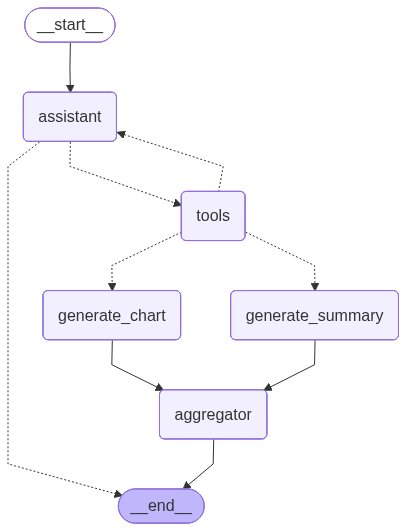

In [45]:
from IPython.display import Image, display

# Draw the graph using Mermaid
display(Image(graph.get_graph().draw_mermaid_png()))

## Let's Test the DataViz Analyst Agent!

To interact with our agent inside this notebook, we'll create a `chat()` helper function. 
This function will:
1. Send the user's message to the graph.
2. Stream the execution steps so we can watch the agent "think" (routing between the assistant, tools, and parallel nodes).
3. Display the final AI text response and render any charts it generates using IPython display tools.

In [37]:
from IPython.display import display, Image, Markdown
from langchain_core.messages import HumanMessage
import base64

def chat(user_message: str, thread_id: str = "clean-session"):
    print(f"\n==================================================================")
    print(f"User: {user_message}")
    print(f"==================================================================\n")
    
    # It will automatically use "clean-session" unless you tell it otherwise
    config = {"configurable": {"thread_id": thread_id}}
    
    for chunk in graph.stream({"messages": [HumanMessage(content=user_message)]}, config, stream_mode="updates"):
        for node_name, state_update in chunk.items():
            print(f"Node Executed: [{node_name}]")
            
            # Print Tool Usage
            if "messages" in state_update:
                last_msg = state_update["messages"][-1]
                if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
                    for tc in last_msg.tool_calls:
                        print(f" Agent decided to use tool: {tc['name']}")
                
                # Print Final Output
                elif getattr(last_msg, "type", "") == "ai" and node_name in ["assistant", "aggregator"]:
                    print(f"\n Final Response:\n{last_msg.content}")
                    
            # Print Charts
            if "chart_image_base64" in state_update and state_update["chart_image_base64"]:
                from IPython.display import display, HTML
                print("\n Generated Chart:")
                img_html = f'<img src="data:image/png;base64,{state_update["chart_image_base64"]}" />'
                display(HTML(img_html))

### Test 1: The Discovery Phase

Before asking for complex charts, let's see how the agent handles a basic data discovery request. According to our System Prompt, the agent should realize it needs to look at the database schema first.


User: What is our total profit?

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: execute_sql_query
  🕵️ [Router] Raw SQL Result: |   SUM(profit) |
|--------------:|
|        207953 |...
  🚀 [Router] Success! Triggering Parallel Nodes!
▶️ Node Executed: [tools]
  --> [Parallel Task A] Generating Chart...
  --> [Parallel Task B] Writing Description...
▶️ Node Executed: [generate_summary]
▶️ Node Executed: [generate_chart]

📊 Generated Chart:



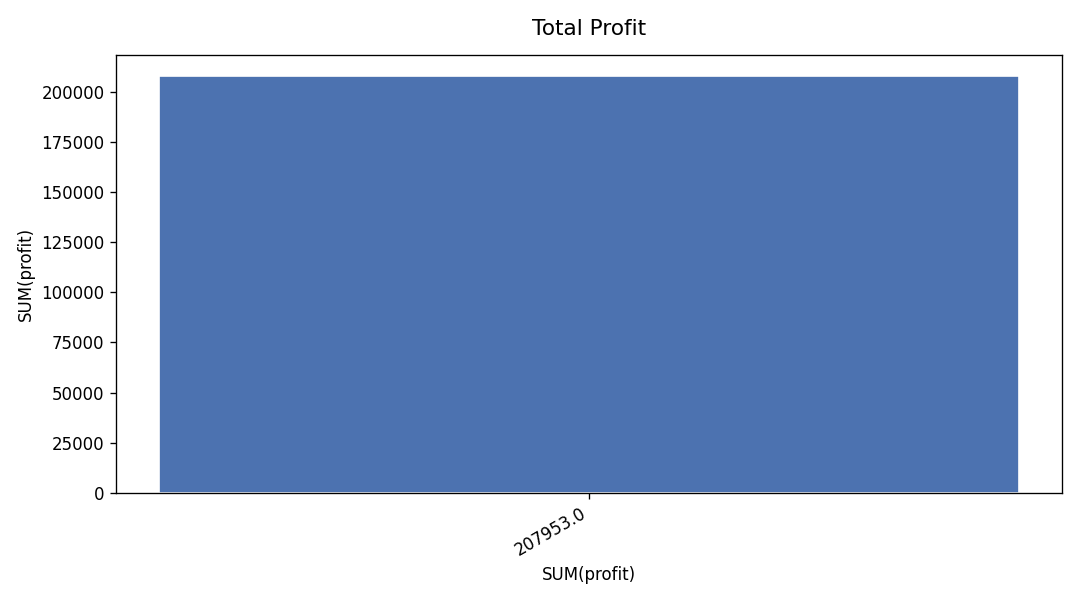

  --> [Fan-in] Aggregating Results...
▶️ Node Executed: [aggregator]

📝 Final Response:
**Analysis Complete:**

The company has achieved a total profit of $207,953, indicating a successful financial performance. This figure represents the cumulative profit earned by the company, showcasing its ability to generate revenue and maintain profitability.


In [38]:
chat("What is our total profit?")


User: Can you break that down by country in a pie chart?

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: execute_sql_query
  🕵️ [Router] Raw SQL Result: | country   |   SUM(profit) |
|:----------|--------------:|
| Australia |       25246.1 |
| Canada  ...
  🚀 [Router] Success! Triggering Parallel Nodes!
▶️ Node Executed: [tools]
  --> [Parallel Task A] Generating Chart...
  --> [Parallel Task B] Writing Description...
▶️ Node Executed: [generate_chart]

📊 Generated Chart:



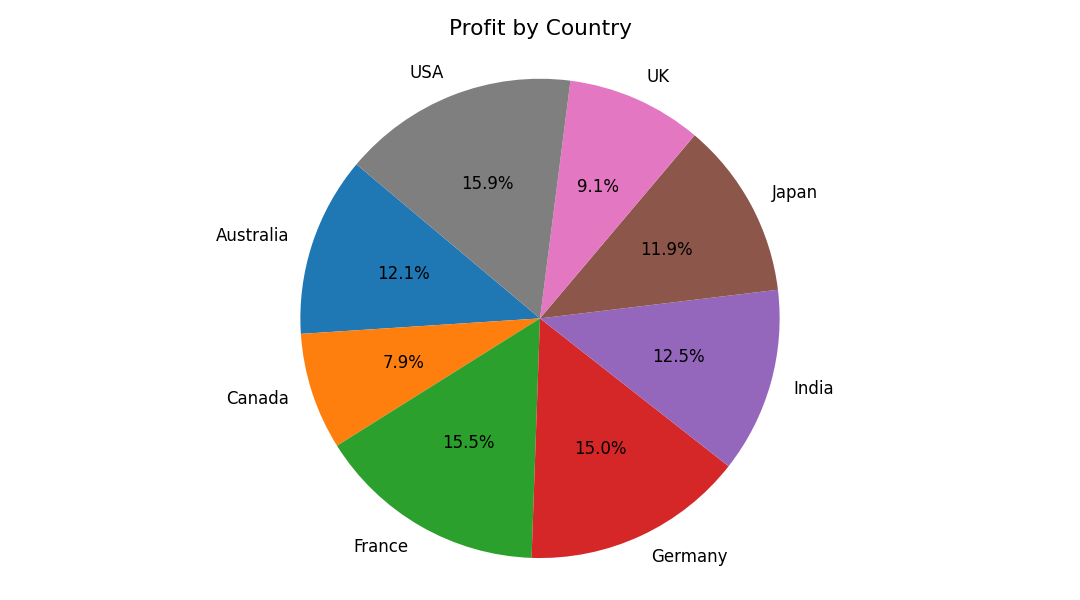

▶️ Node Executed: [generate_summary]
  --> [Fan-in] Aggregating Results...
▶️ Node Executed: [aggregator]

📝 Final Response:
**Analysis Complete:**

Our company operates globally, generating significant profits from various countries, with the top contributors being the USA and France, accounting for substantial revenue. The combined profits from these two countries alone total $66200.9, a substantial portion of our overall global revenue.


In [40]:
chat("Can you break that down by country in a pie chart?")

In [41]:
chat("What tables do we currently have in our database, and what kind of data is in them?")


User: What tables do we currently have in our database, and what kind of data is in them?

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: get_database_schema
  🕵️ [Router] Raw SQL Result: Database Schema:
- Table: sales
  * order_id (INTEGER)
  * date (TEXT)
  * country (TEXT)
  * produc...
  ↩️ [Router] No data retrieved, returning to assistant
▶️ Node Executed: [tools]
▶️ Node Executed: [assistant]

📝 Final Response:
**Analysis Complete:**

Our database currently contains one table named 'sales'. This table stores information about sales transactions, including the order ID, date, country, product, segment, quantity, sales amount, discount, and profit.


### Test 2: Generate a Chart with Parallel Execution

Now let's test the parallel execution by asking for a chart. Watch how the agent:
1. Fetches the data with SQL
2. Triggers BOTH the chart generator AND summary writer simultaneously
3. Aggregates the results


User: Please generate a bar chart showing the top 5 total sales amount for each country.

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: execute_sql_query
  🕵️ [Router] Raw SQL Result: | country   |   SUM(sales_amount) |
|:----------|--------------------:|
| Germany   |              1...
  🚀 [Router] Success! Triggering Parallel Nodes!
▶️ Node Executed: [tools]
  --> [Parallel Task A] Generating Chart...
  --> [Parallel Task B] Writing Description...
▶️ Node Executed: [generate_chart]

📊 Generated Chart:



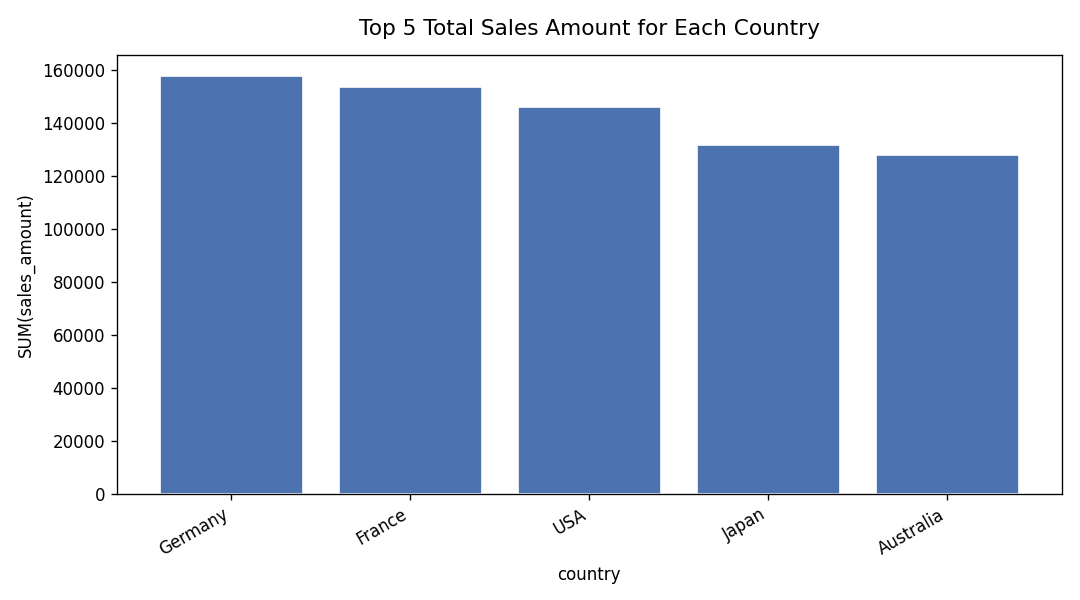

▶️ Node Executed: [generate_summary]
  --> [Fan-in] Aggregating Results...
▶️ Node Executed: [aggregator]

📝 Final Response:
**Analysis Complete:**

Here's a 2-sentence business summary based on the provided data:

Our company has experienced significant sales growth across key international markets, with Germany leading the way at $157,834 in total sales. The top five countries for sales are Germany, France, USA, Japan, and Australia, with the USA and France closely following Germany in terms of total sales.


In [42]:
chat("Please generate a bar chart showing the top 5 total sales amount for each country.")

### Test 3: Average Discount by Country

This was the query that originally hit the rate limit. With our retry logic, it should now work!


User: Show me a bar chart comparing the average discount given in each country.

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: execute_sql_query
  🕵️ [Router] Raw SQL Result: | country   |   average_discount |
|:----------|-------------------:|
| Australia |           0.1546...
  🚀 [Router] Success! Triggering Parallel Nodes!

▶️ Node Executed: [tools]
  --> [Parallel Task A] Generating Chart...
  --> [Parallel Task B] Writing Description...

▶️ Node Executed: [generate_summary]

▶️ Node Executed: [generate_chart]

📊 Generated Chart:


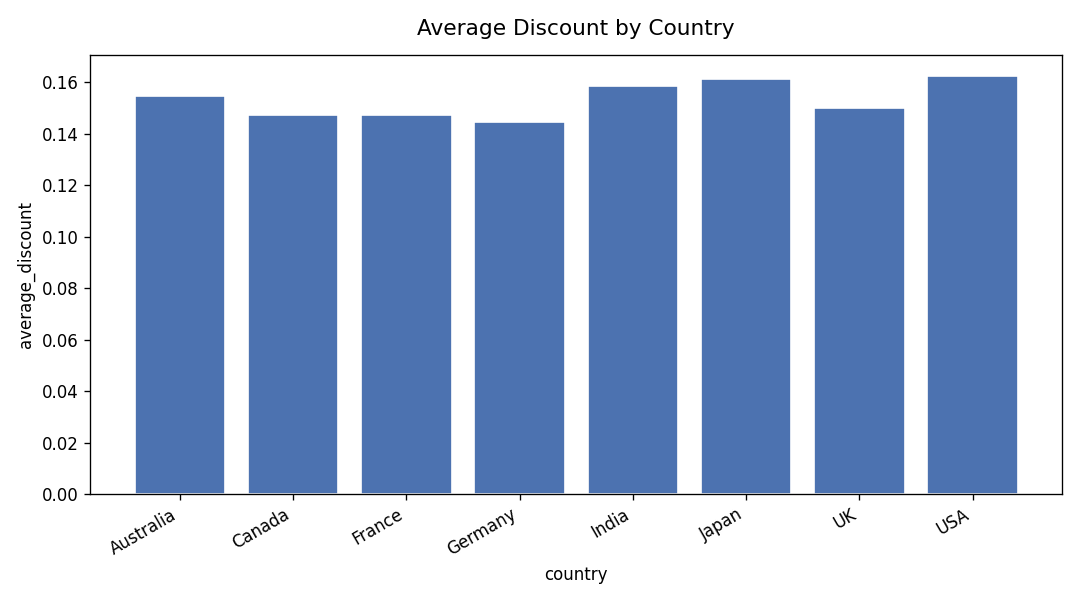

  --> [Fan-in] Aggregating Results...

▶️ Node Executed: [aggregator]

📝 Final Response:


**Analysis Complete:**

Here's a 2-sentence business summary based on the provided data:

Our analysis of international market trends reveals that countries such as Australia, India, and Japan tend to offer higher average discounts to customers, while countries like Canada, France, Germany, and the UK offer relatively lower discounts. The USA stands out as an outlier, with the highest average discount among the countries analyzed, indicating potential opportunities for businesses to capitalize on this trend.

In [13]:
chat("Show me a bar chart comparing the average discount given in each country.")


User: Show me a line chart tracking our total profit over time based on the order dates top 5

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: execute_sql_query
  🕵️ [Router] Raw SQL Result: | date       |   SUM(profit) |
|:-----------|--------------:|
| 2025-05-23 |       4488.81 |
| 2025-...
  🚀 [Router] Success! Triggering Parallel Nodes!
▶️ Node Executed: [tools]
  --> [Parallel Task A] Generating Chart...
  --> [Parallel Task B] Writing Description...
▶️ Node Executed: [generate_summary]
▶️ Node Executed: [generate_chart]

📊 Generated Chart:



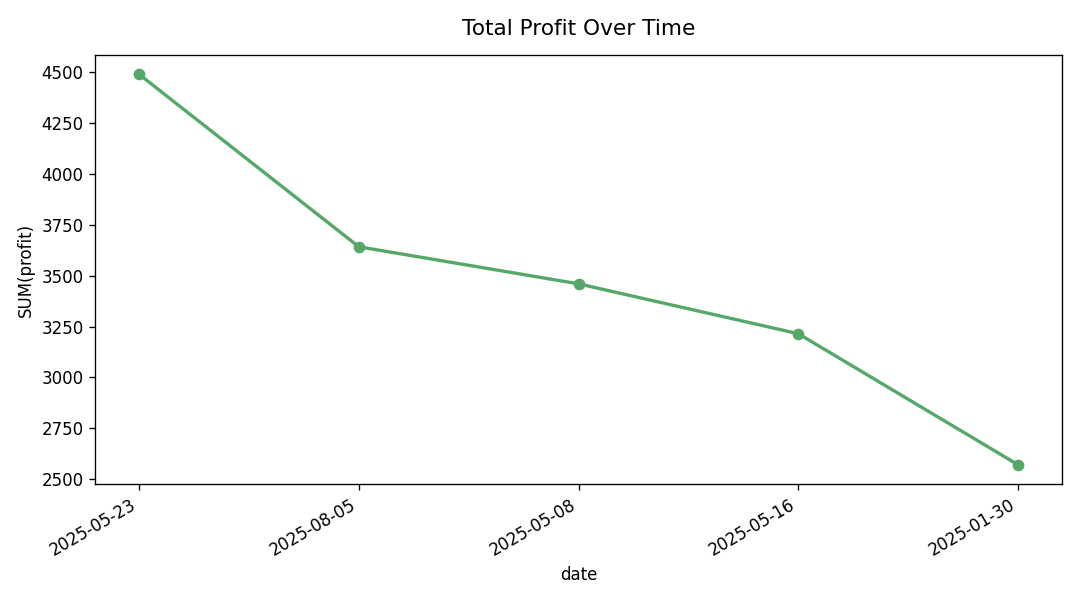

  --> [Fan-in] Aggregating Results...
▶️ Node Executed: [aggregator]

📝 Final Response:
**Analysis Complete:**

Our company has experienced fluctuating profits over the past year, with a total profit of $14,578.06 as of the latest available data point in 2025. The highest profit recorded was $4,488.81 on May 23, 2025, while the lowest was $2,571.31 on January 30, 2025.


In [44]:
chat("Show me a line chart tracking our total profit over time based on the order dates top 5")


User: Show me a line chart tracking our total profit over time based on the order dates

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: get_database_schema
  🕵️ [Router] Raw SQL Result: Database Schema:
- Table: sales
  * order_id (INTEGER)
  * date (TEXT)
  * country (TEXT)
  * produc...
  ↩️ [Router] No data retrieved, returning to assistant

▶️ Node Executed: [tools]

▶️ Node Executed: [assistant]
   🛠️ Agent decided to use tool: execute_sql_query
  🕵️ [Router] Raw SQL Result: | date       |   total_profit |
|:-----------|---------------:|
| 2025-01-01 |         276.14 |
| 20...
  🚀 [Router] Success! Triggering Parallel Nodes!

▶️ Node Executed: [tools]
  --> [Parallel Task A] Generating Chart...
  --> [Parallel Task B] Writing Description...

▶️ Node Executed: [generate_summary]

▶️ Node Executed: [generate_chart]

📊 Generated Chart:


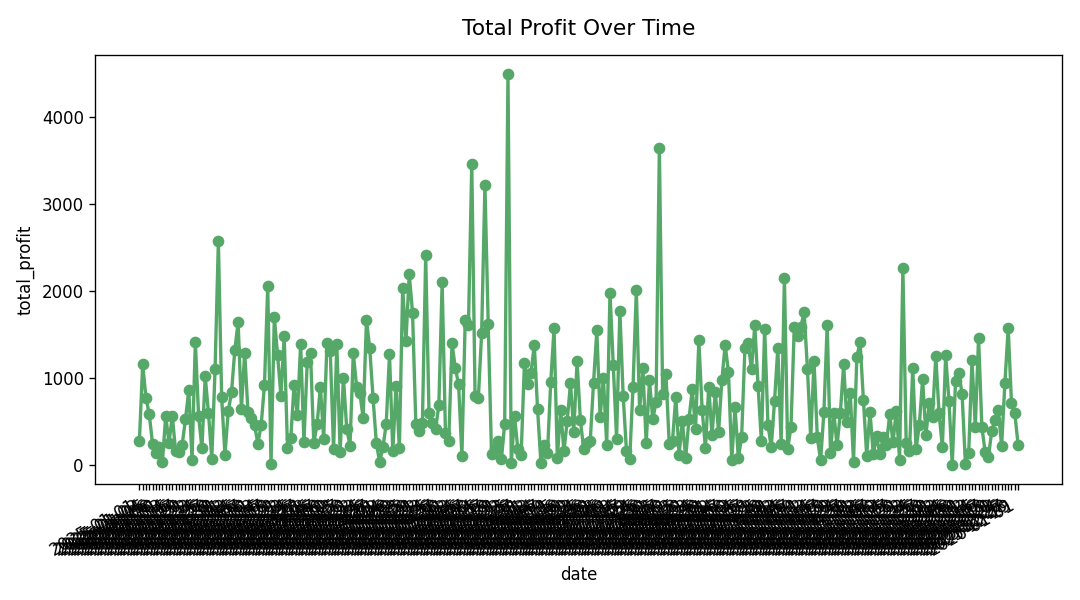

  --> [Fan-in] Aggregating Results...

▶️ Node Executed: [aggregator]

📝 Final Response:


**Analysis Complete:**

Here is a 2-sentence business summary based on the provided data:

Our company experienced significant revenue growth throughout 2025, with a total profit of $[insert total profit] for the year, indicating a strong and consistent performance across various periods. The data suggests a seasonal pattern, with higher profits typically occurring in the first and third quarters, and lower profits in the second and fourth quarters, which may be influenced by factors such as market demand and operational efficiency.

In [18]:
chat("Show me a line chart tracking our total profit over time based on the order dates", thread_id="fresh-start-1")